In [1]:
!pip install tensorflow librosa matplotlib scikit-learn pandas numpy

In [2]:
import os
import numpy as np
import pandas as pd

import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.utils import to_categorical

In [12]:
import os

# Dataset path
dataset_path = r"C:\Users\ADMIN\Downloads\audio_speech_actors_01-24"
# Check folder exists
print(os.path.isdir(dataset_path))

True


In [13]:
#MFCC feature extraction function 
def extract_features(file_path):

    audio, sample_rate = librosa.load(
        file_path,
        duration=3,
        offset=0.5
    )

    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    mfccs_scaled = np.mean(mfccs.T, axis=0)

    return mfccs_scaled

In [14]:
#load_audio_file
paths = []
labels = []

for actor_folder in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor_folder)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            file_path = os.path.join(actor_path, file)

            emotion = file.split("-")[2]

            paths.append(file_path)
            labels.append(emotion)

print("Total Audio Files:", len(paths))

Total Audio Files: 180


In [15]:
#extract MFCC feature 
features = []

for path in paths:

    data = extract_features(path)

    features.append(data)

X = np.array(features)

print(X.shape)

(180, 40)


In [16]:
#encode emotion labels
encoder = LabelEncoder()
y = encoder.fit_transform(labels)
y = to_categorical(y)
print(y.shape)

(180, 8)


In [17]:
#split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#reshape data for LSTM
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

print(X_train.shape)

(144, 40, 1)


In [20]:
#build LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input

model = Sequential()

model.add(Input(shape=(40,1)))

model.add(
    LSTM(
        128,
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(y.shape[1], activation='softmax'))

model = Sequential()

model.add(
    LSTM(
        128,
        input_shape=(40,1),
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(y.shape[1], activation='softmax'))

In [23]:
#compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.6111 - loss: 1.0077 - val_accuracy: 0.2778 - val_loss: 1.6534
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6042 - loss: 0.9497 - val_accuracy: 0.5556 - val_loss: 1.4745
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6111 - loss: 0.9515 - val_accuracy: 0.5000 - val_loss: 1.3716
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6389 - loss: 0.9345 - val_accuracy: 0.4722 - val_loss: 1.2798
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6806 - loss: 0.8507 - val_accuracy: 0.5833 - val_loss: 1.3591
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6528 - loss: 0.8565 - val_accuracy: 0.4444 - val_loss: 1.5690
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6736 - loss: 0.8195 - val_accuracy: 0.4167 - val_loss: 1.4005
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6667 - loss: 0.7962 - val_accuracy: 0.5278 - val_loss: 1.3601

In [27]:
#train model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9792 - loss: 0.0521 - val_accuracy: 0.5000 - val_loss: 2.2637
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9861 - loss: 0.0684 - val_accuracy: 0.4722 - val_loss: 2.4210
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9861 - loss: 0.0556 - val_accuracy: 0.5556 - val_loss: 2.2686
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9861 - loss: 0.0535 - val_accuracy: 0.5278 - val_loss: 2.2569
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9931 - loss: 0.0307 - val_accuracy: 0.5000 - val_loss: 2.3085
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9861 - loss: 0.0283 - val_accuracy: 0.5000 - val_loss: 2.3603
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9931 - loss: 0.0396 - val_accuracy: 0.4722 - val_loss: 2.3870
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9861 - loss: 0.0371 - val_accuracy: 0.4444 - val_loss: 2.4490


In [28]:
#evaluate accuracy
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5556 - loss: 2.5939
Accuracy: 0.5555555820465088


In [29]:
#predict emotion 
predictions = model.predict(X_test)

predicted_emotion = np.argmax(predictions[0])

emotion_name = encoder.inverse_transform([predicted_emotion])

print("Predicted Emotion:", emotion_name)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step
Predicted Emotion: ['03']


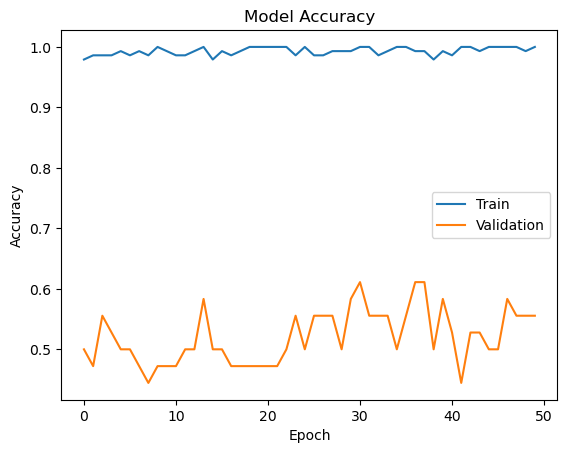

In [30]:
#accuracy_graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

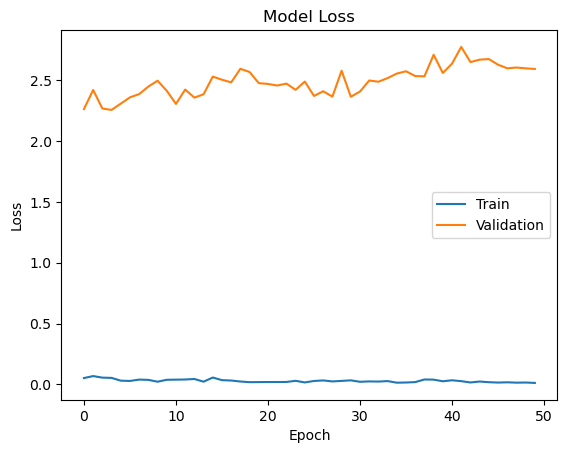

In [31]:
#loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


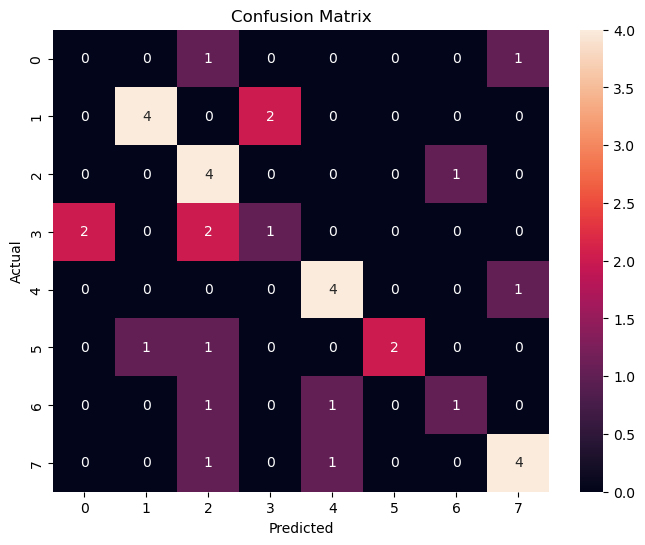

In [32]:
#confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
#classifier report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.80      0.67      0.73         6
           2       0.40      0.80      0.53         5
           3       0.33      0.20      0.25         5
           4       0.67      0.80      0.73         5
           5       1.00      0.50      0.67         4
           6       0.50      0.33      0.40         3
           7       0.67      0.67      0.67         6

    accuracy                           0.56        36
   macro avg       0.55      0.50      0.50        36
weighted avg       0.59      0.56      0.55        36



In [34]:
#emotion label name
emotion_labels = {
    0:"Neutral",
    1:"Calm",
    2:"Happy",
    3:"Sad",
    4:"Angry",
    5:"Fearful",
    6:"Disgust",
    7:"Surprised"
}

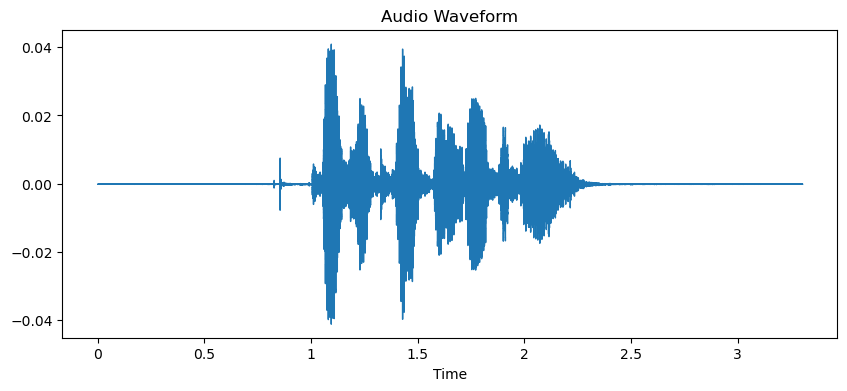

In [35]:
#sample audio waveframe 
audio_path = paths[0]

audio, sample_rate = librosa.load(audio_path)

plt.figure(figsize=(10,4))

librosa.display.waveshow(audio, sr=sample_rate)

plt.title("Audio Waveform")

plt.show()

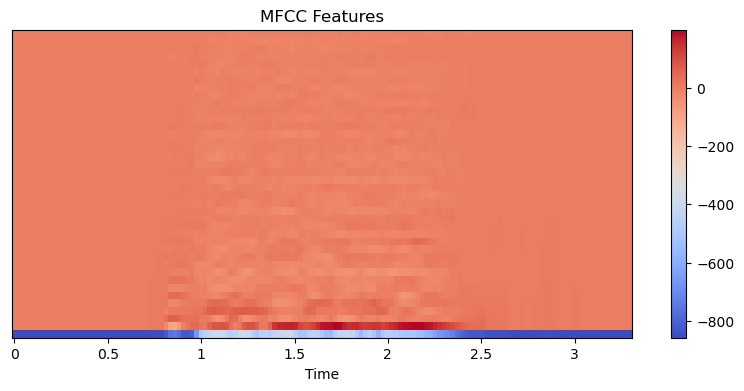

In [36]:
#MFCC visualization 
mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

plt.figure(figsize=(10,4))

librosa.display.specshow(mfccs, x_axis='time')

plt.colorbar()

plt.title("MFCC Features")

plt.show()

In [42]:
#accuracy percentage 
print("Accuracy:", accuracy * 100, "%")

#save model 
model.save("emotion_recognition_model.h5")

#add project architecture diagram
print("Audio Input")
print("↓")
print("MFCC Feature Extraction")
print("↓")
print("LSTM Model")
print("↓")
print("Emotion Prediction")

model.save("emotion_recognition_model.keras")

print("Model Saved Successfully")

Accuracy: 55.55555820465088 %
Audio Input
↓
MFCC Feature Extraction
↓
LSTM Model
↓
Emotion Prediction
Model Saved Successfully


Total Audio Files: 180
Feature Extraction Completed
Feature Shape: (180, 40)
Reshaped X: (180, 40, 1)
Label Shape: (180, 8)
X_train: (144, 40, 1)
X_test: (36, 40, 1)
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.1181 - loss: 2.0782 - val_accuracy: 0.1667 - val_loss: 2.0676
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1667 - loss: 2.0370 - val_accuracy: 0.1667 - val_loss: 2.0518
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1944 - loss: 2.0036 - val_accuracy: 0.1667 - val_loss: 2.0370
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2153 - loss: 1.9918 - val_accuracy: 0.1111 - val_loss: 2.0398
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2431 - loss: 1.9726 - val_accuracy: 0.1389 - val_loss: 2.0462
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1389 - loss: 2.0462
Model Accuracy: 0.1388888955116272
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step
Predicted Emotion Code: 7
Detected Emotion: Surprised
😲 Surprised
R

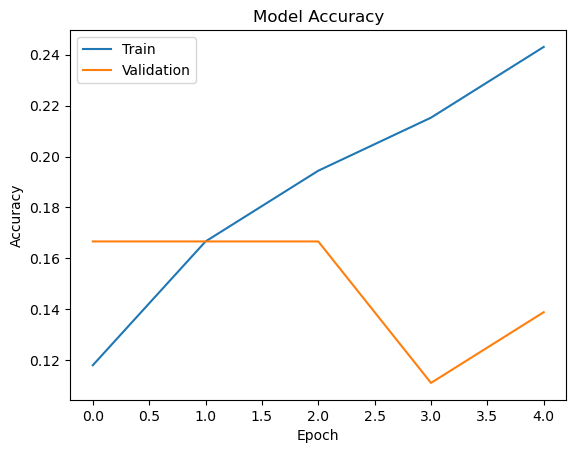

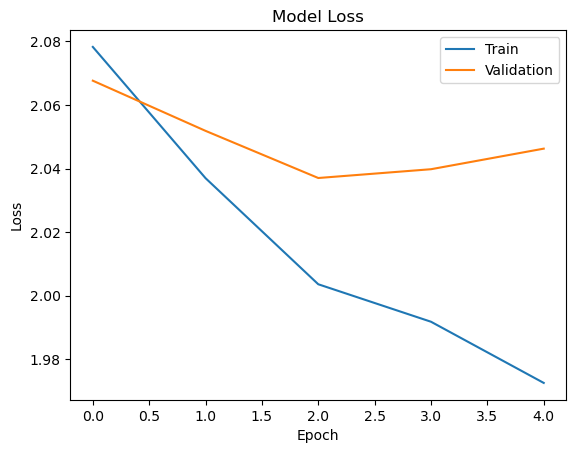

Model Saved Successfully


In [12]:
#example

# =========================================
# IMPORT LIBRARIES
# =========================================

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout,
    Input
)

from tensorflow.keras.utils import to_categorical

# =========================================
# DATASET PATH
# =========================================

dataset_path = r"C:\Users\ADMIN\Downloads\audio_speech_actors_01-24"

# =========================================
# LOAD AUDIO FILE PATHS & LABELS
# =========================================

paths = []
labels = []

for actor_folder in os.listdir(dataset_path):

    actor_path = os.path.join(
        dataset_path,
        actor_folder
    )

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                file_path = os.path.join(
                    actor_path,
                    file
                )

                # Emotion code
                emotion = file.split("-")[2]

                paths.append(file_path)

                labels.append(emotion)

print("Total Audio Files:",
      len(paths))

# =========================================
# MFCC FEATURE EXTRACTION FUNCTION
# =========================================

def extract_features(file_path):

    audio, sample_rate = librosa.load(
        file_path,
        duration=3,
        offset=0.5
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    mfcc_scaled = np.mean(
        mfcc.T,
        axis=0
    )

    return mfcc_scaled

# =========================================
# EXTRACT FEATURES
# =========================================

features = []

for path in paths:

    data = extract_features(path)

    features.append(data)

print("Feature Extraction Completed")

# =========================================
# CONVERT FEATURES TO NUMPY ARRAY
# =========================================

X = np.array(features)

print("Feature Shape:",
      X.shape)

# =========================================
# RESHAPE FOR LSTM
# =========================================

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print("Reshaped X:",
      X.shape)

# =========================================
# LABEL ENCODING
# =========================================

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

y = to_categorical(y)

print("Label Shape:",
      y.shape)

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:",
      X_train.shape)

print("X_test:",
      X_test.shape)

# =========================================
# BUILD LSTM MODEL
# =========================================

model = Sequential()

model.add(Input(shape=(40,1)))

model.add(
    LSTM(
        128,
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

# 8 emotion classes
model.add(Dense(8, activation='softmax'))

# =========================================
# COMPILE MODEL
# =========================================

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# =========================================
# TRAIN MODEL
# =========================================

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================================
# MODEL EVALUATION
# =========================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Model Accuracy:",
      accuracy)

# =========================================
# PREDICT EMOTION
# =========================================

predictions = model.predict(X_test)

predicted_emotion = np.argmax(
    predictions[0]
)

print("Predicted Emotion Code:",
      predicted_emotion)

# =========================================
# EMOTION LABELS
# =========================================

emotion_labels = {
    0: "Neutral",
    1: "Calm",
    2: "Happy",
    3: "Sad",
    4: "Angry",
    5: "Fearful",
    6: "Disgust",
    7: "Surprised"
}

emotion = emotion_labels[
    predicted_emotion
]

print("Detected Emotion:",
      emotion)

# =========================================
# EMOTION BASED RESPONSE
# =========================================

if emotion == "Happy":

    print("😊 Happy")

    print(
        "Recommendation: Keep smiling and stay positive!"
    )

elif emotion == "Sad":

    print("😢 Sad")

    print(
        "Recommendation: Take rest and relax."
    )

elif emotion == "Angry":

    print("😠 Angry")

    print(
        "Recommendation: Practice meditation."
    )

elif emotion == "Fearful":

    print("😨 Fearful")

    print(
        "Recommendation: Stay calm and relax."
    )

elif emotion == "Surprised":

    print("😲 Surprised")

    print(
        "Recommendation: Stay positive."
    )

else:

    print("😐 Neutral")

    print(
        "Recommendation: Maintain healthy routine."
    )

# =========================================
# ACCURACY GRAPH
# =========================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# =========================================
# LOSS GRAPH
# =========================================

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# =========================================
# SAVE MODEL
# =========================================

model.save(
    "emotion_recognition_model.keras"
)

print(
    "Model Saved Successfully"
)
